In [12]:
# Linear Regression on California Housing Dataset
# Libraries: scikit-learn, numpy, pandas, matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
# 1. Load dataset
df = pd.read_csv("Housing.csv")   # California housing dataset

In [3]:
# 2. Inspect columns
print("Columns:", df.columns)

Columns: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


In [4]:
# 3. Define features (X) and target (y)
# We'll use a few numeric predictors
X = df[['longitude', 'latitude', 'housing_median_age',
        'total_rooms', 'total_bedrooms', 'population',
        'households', 'median_income']]

y = df['median_house_value']

In [5]:
# 4. Handle missing values (if any)
X = X.fillna(X.mean())

In [6]:
# 5. Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# 6. Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
# 7. Predict on test set
y_pred = model.predict(X_test)

In [9]:
# 8. Evaluate model
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Intercept: -3578224.2348188055
Coefficients: [-4.26323917e+04 -4.24500719e+04  1.18280965e+03 -8.18797708e+00
  1.16260128e+02 -3.84922131e+01  4.63425720e+01  4.05384044e+04]
Mean Squared Error: 5052953703.901642
R² Score: 0.6143987268246014


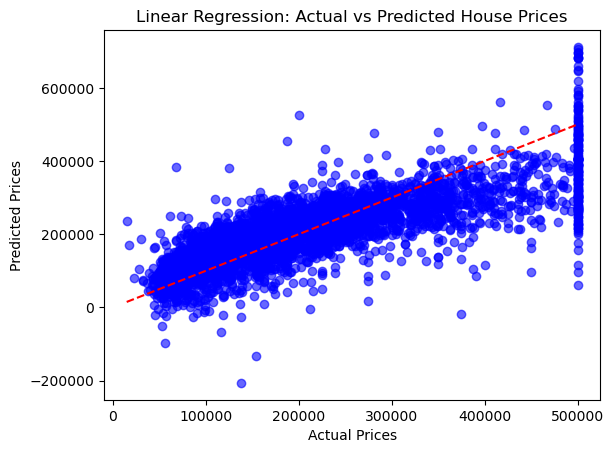

In [11]:
# 9. Visualization: Actual vs Predicted
plt.scatter(y_test, y_pred, color="blue", alpha=0.6)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # reference line
plt.show()